In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Covariance from sim vs analytic

In [2]:
# cosmogrid sim result
# This file includes map3 as well, we discard them to focus on 2pt
ave_sim = np.loadtxt('../data/covariance/ave_2pcf_map3.dat')[:400]
cov_sim = np.loadtxt('../data/covariance/cov_2pcf_map3.dat')[:400,:400]

# public data
hdul = fits.open('../data/dv/sim_2pt-NLA.fits')
ave_ana = np.hstack([hdul[2].data['VALUE'], hdul[3].data['VALUE']])
cov_ana = hdul[1].data[:400, :400]

## diangonal

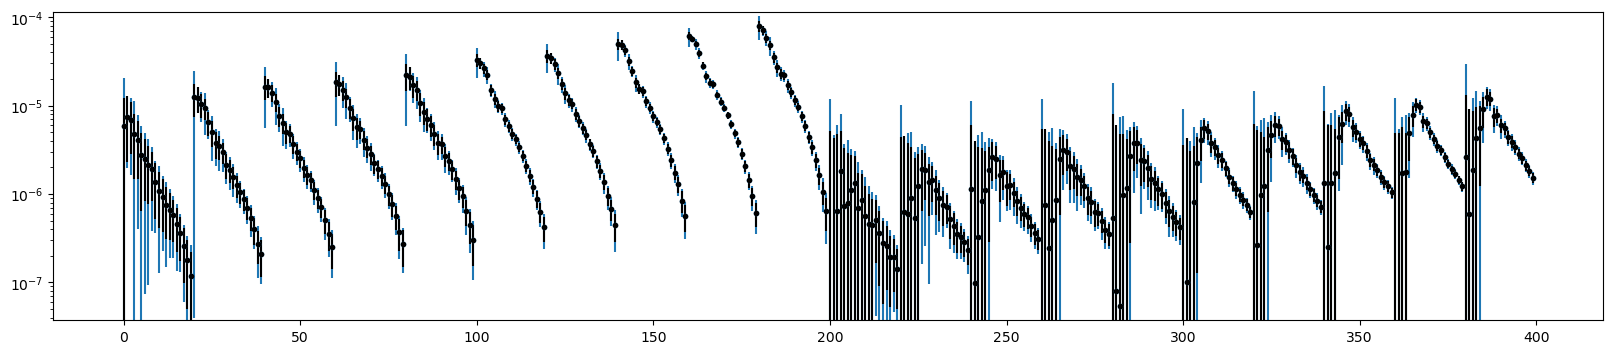

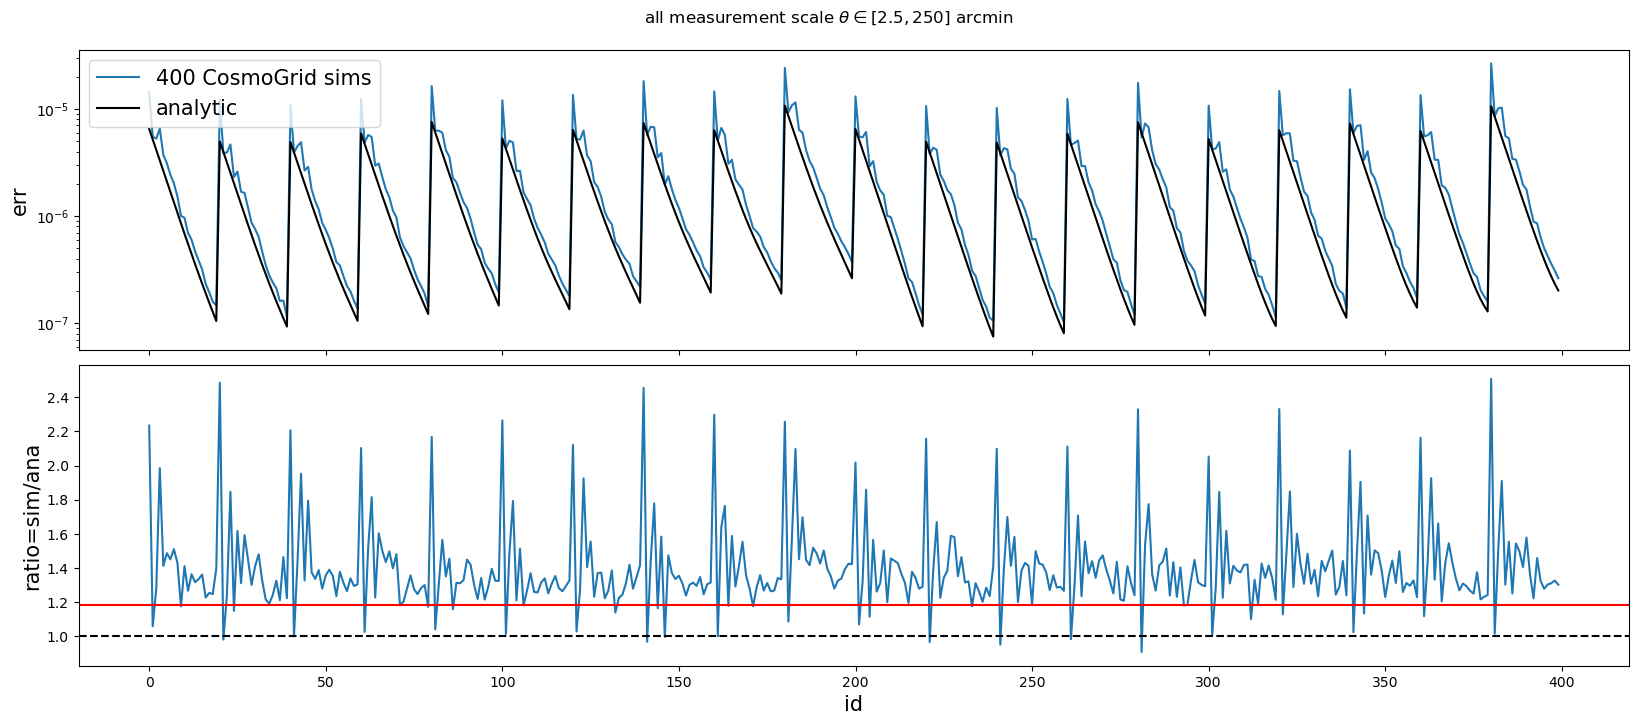

In [3]:
y = ave_sim[:400]
x = np.arange(y.size)
e_sim = np.diag(cov_sim)**0.5
e_ana = np.diag(cov_ana)**0.5

# signal
plt.figure(figsize=(20, 4))
plt.yscale('log')
plt.errorbar(x, y, yerr=e_sim, fmt='.')
plt.errorbar(x, y, yerr=e_ana, fmt='.', color='k')
plt.show()

# cosmology difference
sigma8_CG = 0.84 # * (0.26/0.3)**0.5
sigma8_DES= 0.759 * (0.29/0.3)**-0.5
ratioCosmo = (sigma8_CG/sigma8_DES)**2

fig, axes = plt.subplots(2,1, figsize=(20,8), sharex=True)
plt.subplots_adjust(wspace=0.3, hspace=0.05)
fig.suptitle(r'all measurement scale $\theta\in[2.5, 250]$ arcmin', y=0.93)
axes[0].plot(x, e_sim, label='400 CosmoGrid sims')
axes[0].plot(x, e_ana, label='analytic', color='k')
axes[1].plot(x, e_sim/e_ana)
axes[1].axhline(1.0, color='k', ls='--')
axes[1].axhline(ratioCosmo, color='r', ls='-')
axes[0].legend(fontsize=15)
axes[0].set_yscale('log')
axes[0].set_ylabel('err', fontsize=15)
axes[1].set_xlabel('id', fontsize=15)
axes[1].set_ylabel('ratio=sim/ana', fontsize=15)
plt.show()

## difference in correlation coefficient

In [4]:
diag= np.diag(cov_sim[:400,:400])
rcc_sim = cov_sim[:400,:400] / np.sqrt(np.outer(diag, diag))

diag= np.diag(cov_ana)
rcc_ana = cov_ana / np.sqrt(np.outer(diag, diag))

0.072833802394554


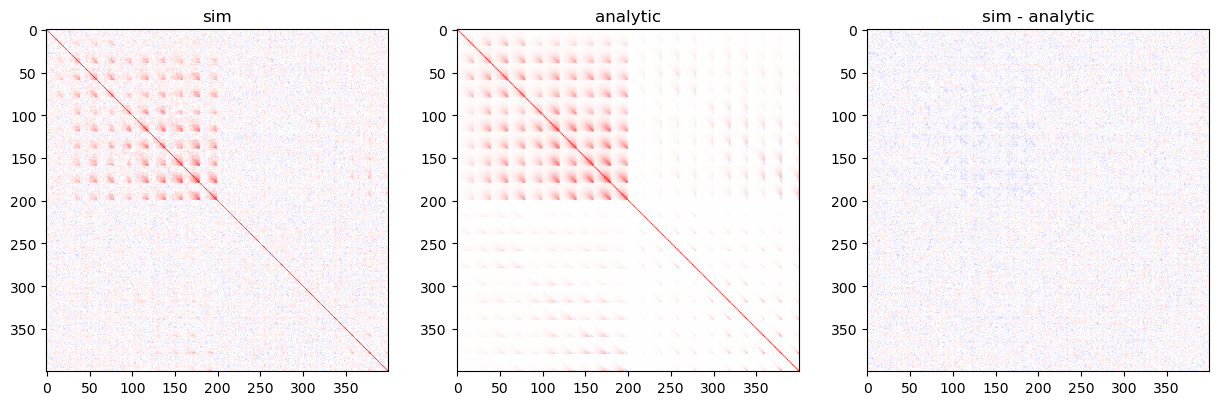

In [14]:
fig, axes = plt.subplots(1,3, figsize=(15, 5))
ax = axes[0]
ax.set_title('sim')
ax.imshow(rcc_sim, cmap='bwr', vmin=-1, vmax=1)
ax = axes[1]
ax.set_title('analytic')
ax.imshow(rcc_ana, cmap='bwr', vmin=-1, vmax=1)
ax = axes[2]
ax.set_title('sim - analytic')
ax.imshow(rcc_sim-rcc_ana, cmap='bwr', vmin=-1, vmax=1)
# print(np.max(np.abs(rcc_sim-rcc_ana)))
print(np.mean(np.abs(rcc_sim-rcc_ana)))
plt.show()

# Diagonalize the covariance using Rotation matrix from analytic covariance

We saw the difference in the covariances from simulation-based and analytic approaches. This can be interpreted as the difference in the cosmological parameters asummed. E.g. analytic covariance is calculated with the (almost) best fit cosmological parameter to DES, while simulation is based on CosmoGrid.

For the joint analysis of 2pt+map3, the most naive approach would be to replace the 2pt auto covariance witht the analytic one. However this breaks the correlation structure between 2pt and map3, and sometimes causes singular for the covariance, i.e. zero determinant (from my experience with gaussian simulation, but I do not fully understand why).

The good point of the analytic covariance is that it knows how the different element of data vector correlates each other. This can be interpreted that the rotation matrix obtained when we diagonalize the analytic covariance is acculate. Actually, this is the reason why the inverse covariance estimate from a bunch of noisy simulations are less accurate than the estimate of covariance itself: because the estimate of rotation matrix (i.e. correlation structure) is difficult to estimate from finite number of realizations (equivalent to the fact that we cannot accurately determine the axis of ellipsoidal in the multidimensional space), we cannot convert the covariance matrix to the inverse of it.
$$
{\rm Cov}^{\rm analytic} = RD^{\rm analytic} R^T
$$

In this sense, it is a good strategy to rely on the correlation structure, i.e. rotation matrix, obtained from analytic covariance. Then what we have to correct for in the simulation-based covariance is that the amplitude of variance, keeping noiseness in the covariance.
$$
D^{\rm sim} \equiv {\rm diag}\left[R^T{\rm Cov}^{\rm sim}R\right]
$$
Then estimate the rescaleing factor as the mean of the diagonal element ratios (we take average because the diagonal element from simulation has noise)
$$
f \equiv {\rm mean}\left[ \frac{D^{\rm analytic}}{D^{\rm sim}} \right]
$$
Finally, we estimate the rescaled covariance as
$$
{\rm Cov}^{\rm sim-resc} \equiv f R D^{\rm sim} R^T
$$

In [6]:
# Diagonalize the analytic covariance
D_ana, R = np.linalg.eig(cov_ana)
# Rotate the simulation-based covariance using the rotation matrix obtained above
D_sim = np.diag((R.T.dot(cov_sim)).dot(R))

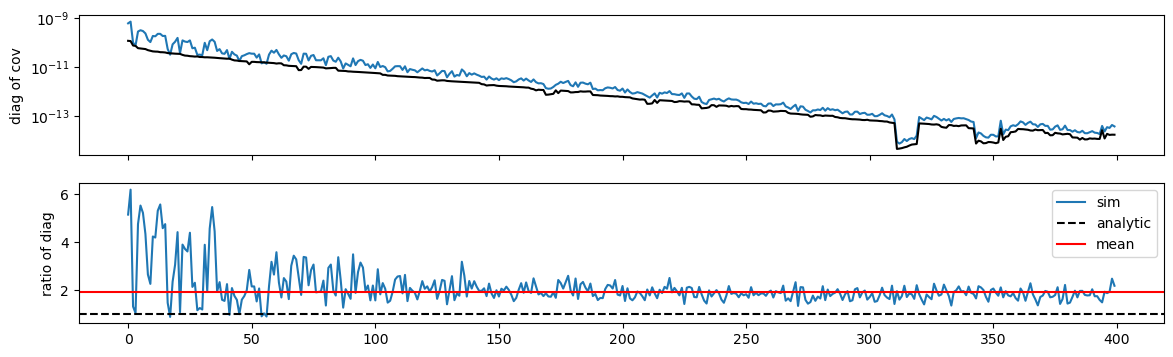

In [24]:
fig, axes = plt.subplots(2,1,figsize=(14, 4), sharex=True)
ax = axes[0]
ax.set_yscale('log')
ax.plot(D_sim)
ax.plot(D_ana, color='k')
ax.set_ylabel('diag of cov')
ax = axes[1]
ax.plot(D_sim/D_ana, label='sim')
ax.set_ylabel('ratio of diag')
ax.axhline(1.0, color='k', ls='--', label='analytic')
f = np.mean(D_ana/D_sim)
ax.axhline(1/f, color='r', label='mean')
ax.legend()
plt.show()

## Rescale diagonal part

In [25]:
cov_sim_resc = f*(R.dot(np.diag(D_sim))).dot(R.T)

In [26]:
diag= np.diag(cov_sim_resc[:400,:400])
rcc_sim_resc = cov_sim_resc[:400,:400] / np.sqrt(np.outer(diag, diag))

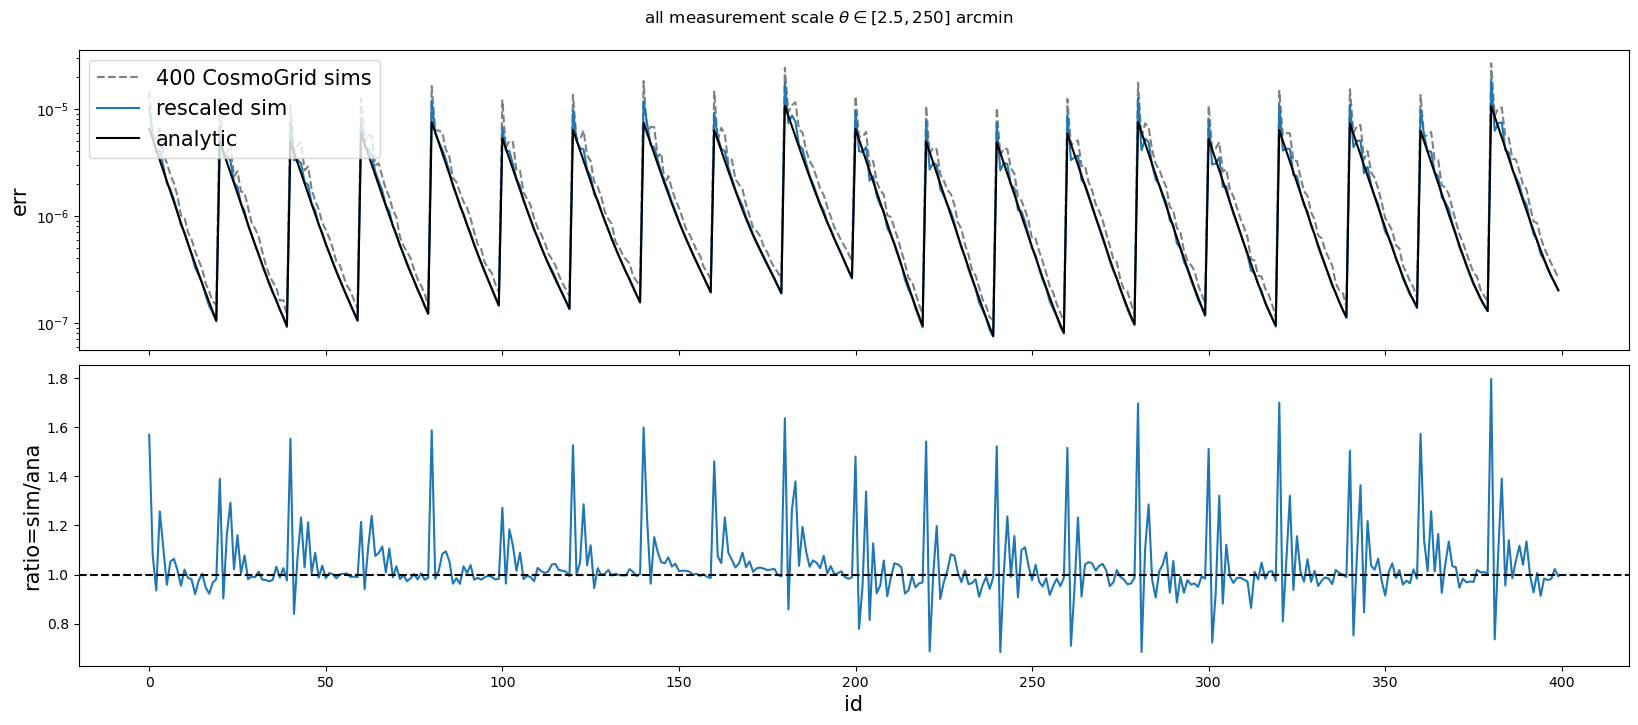

In [27]:
y = ave_sim[:400]
x = np.arange(y.size)
e_sim = np.diag(cov_sim)**0.5
e_sim_resc = np.diag(cov_sim_resc)**0.5
e_ana = np.diag(cov_ana)**0.5

fig, axes = plt.subplots(2,1, figsize=(20,8), sharex=True)
plt.subplots_adjust(wspace=0.3, hspace=0.05)
fig.suptitle(r'all measurement scale $\theta\in[2.5, 250]$ arcmin', y=0.93)
axes[0].plot(x, e_sim, label='400 CosmoGrid sims', ls='--', color='gray')
axes[0].plot(x, e_sim_resc, label='rescaled sim')
axes[0].plot(x, e_ana, label='analytic', color='k')
axes[1].plot(x, e_sim_resc/e_ana)
axes[1].axhline(1.0, color='k', ls='--')
axes[0].legend(fontsize=15)
axes[0].set_yscale('log')
axes[0].set_ylabel('err', fontsize=15)
axes[1].set_xlabel('id', fontsize=15)
axes[1].set_ylabel('ratio=sim/ana', fontsize=15)
plt.show()

0.01029867375710677


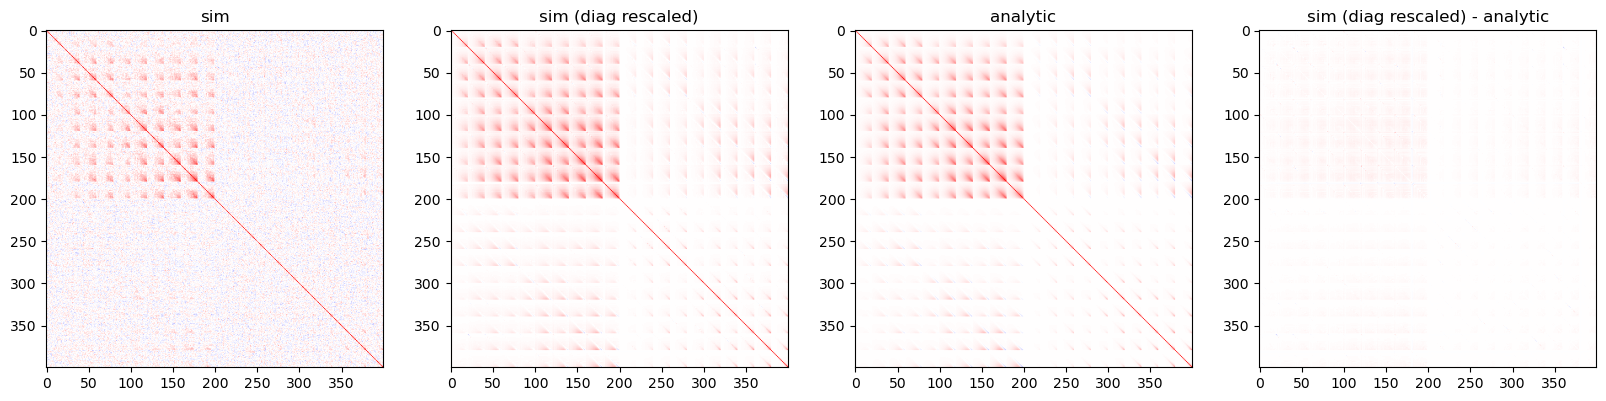

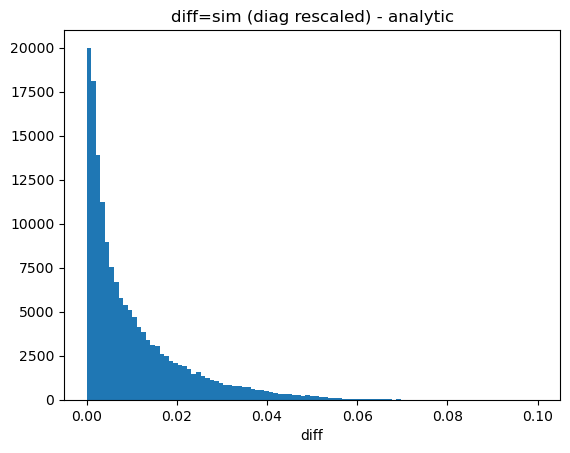

In [28]:
fig, axes = plt.subplots(1,4, figsize=(20, 5))
ax = axes[0]
ax.set_title('sim')
ax.imshow(rcc_sim, cmap='bwr', vmin=-1, vmax=1)
ax = axes[1]
ax.set_title('sim (diag rescaled)')
ax.imshow(rcc_sim_resc, cmap='bwr', vmin=-1, vmax=1)
ax = axes[2]
ax.set_title('analytic')
ax.imshow(rcc_ana, cmap='bwr', vmin=-1, vmax=1)
ax = axes[3]
ax.set_title('sim (diag rescaled) - analytic')
ax.imshow(rcc_sim_resc-rcc_ana, cmap='bwr', vmin=-1, vmax=1)
diff = np.abs(rcc_sim_resc-rcc_ana)
print(np.mean(diff))
plt.show()

plt.figure()
plt.title('diff=sim (diag rescaled) - analytic')
plt.xlabel('diff')
plt.hist(diff.ravel(), bins=np.linspace(0, 0.1, 100))
plt.show()

## cross-covariance part
Same can be applied to the cross-covariance. However, the cross-covariance is for (2pt) x (3pt), so the rescaling factor would be roughly speaking square-root of that applied to the auto-covariance.

In [31]:
cov_sim_cross = np.loadtxt('../data/covariance/cov_2pcf_map3.dat')[400:,:400]
cov_sim_cross_resc = cov_sim_cross * f**0.5

## Note:
Note that this is the rescaling of the 2pt part.
We still have to think about the rescaling of 3pt part as well. We could derive the scaling relation of 3pt part by assuming Gaussian.